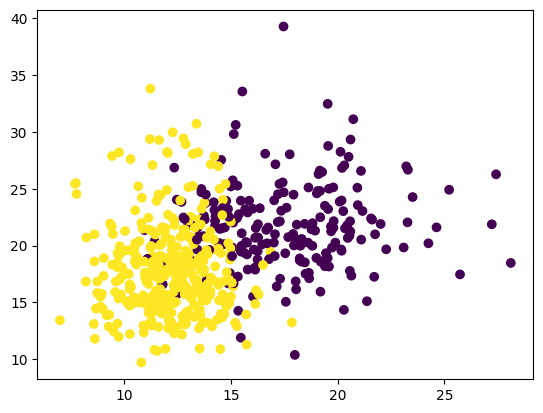

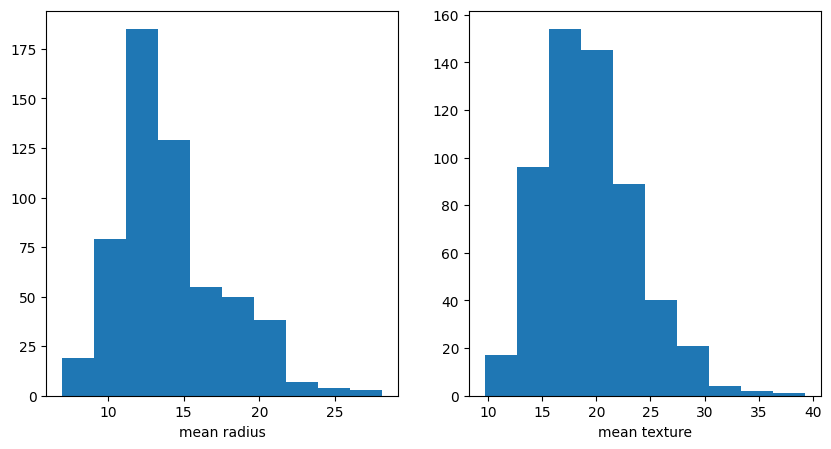

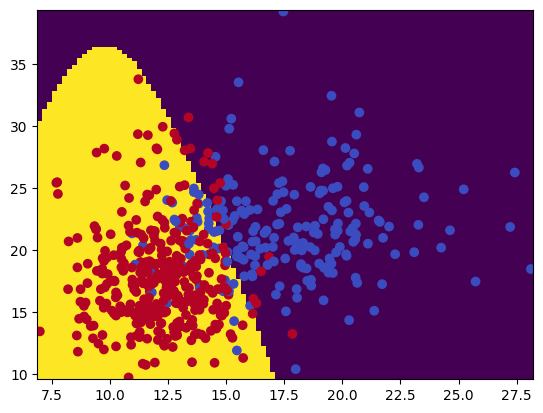

[[164  48]
 [ 17 340]]
Accuracy=  0.8857644991212654
F1_score=  0.912751677852349


In [59]:
import pandas as pd
from pandas import read_csv
from sklearn.datasets import load_breast_cancer
import numpy as np
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

data = load_breast_cancer()

X = data.data[:, :2]
y = data.target

df = pd.DataFrame(X, columns=data.feature_names[:2])
df['target'] = y
df['target'].value_counts()

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

plt.figure(figsize=(10, 5))
for i in range(2):
    plt.subplot(1, 2, i+1)
    plt.hist(X[:, i])
    plt.xlabel(data.feature_names[i])
plt.show()

gaussian_nb = GaussianNB()
gaussian_nb.fit(X, y)
y_predict = gaussian_nb.predict(X)

xx0 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
xx1 = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
xx0_grid, xx1_grid  = np.meshgrid(xx0, xx1)
xx = np.c_[xx0_grid.ravel(), xx1_grid.ravel()]
yy = gaussian_nb.predict(xx)
yy1 = yy.reshape(xx0_grid.shape)

plt.pcolormesh(xx0_grid,xx1_grid, yy1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.show()

print(confusion_matrix(y, y_predict))
print('Accuracy= ', metrics.accuracy_score(y, y_predict))
print('F1_score= ', metrics.f1_score(y, y_predict))

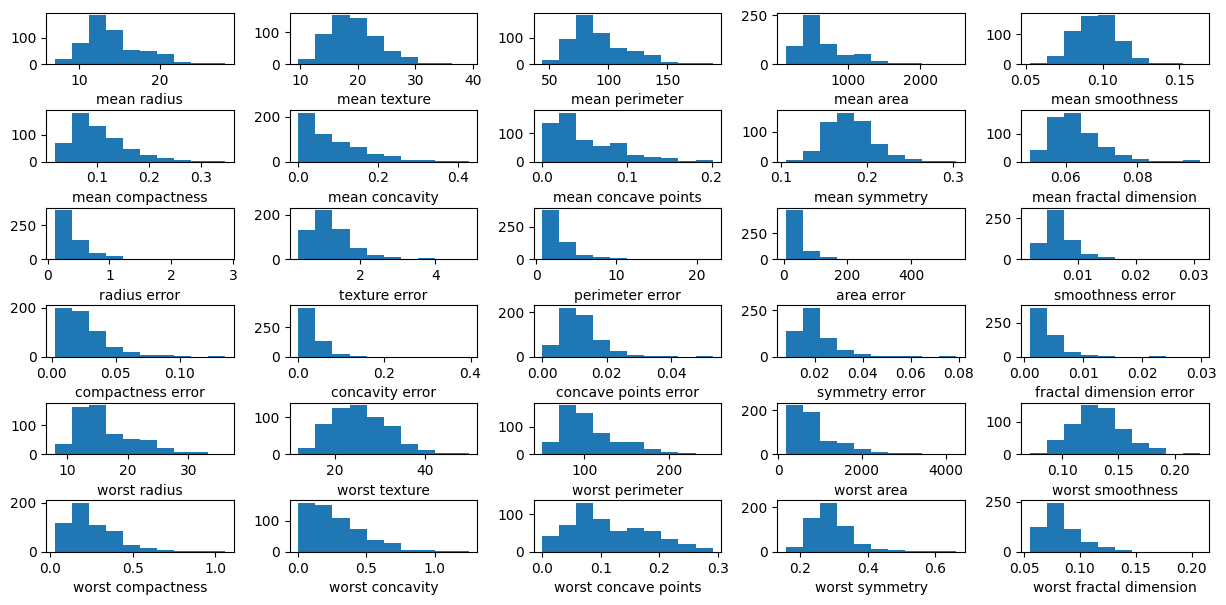

[[189  23]
 [ 10 347]]
Accuracy=  0.9420035149384886
F1_score=  0.9546079779917469


In [65]:
X = data.data
y = data.target

f = plt.figure(figsize=(15, 7))
for i in range(30):
    plt.subplot(6, 5, i+1)
    plt.hist(X[:, i])
    plt.xlabel(data.feature_names[i])
f.subplots_adjust(hspace=0.9,wspace=0.3)
plt.show()

gaussian_nb.fit(X, y)
y_predict = gaussian_nb.predict(X)

print(confusion_matrix(y, y_predict))
print('Accuracy= ', metrics.accuracy_score(y, y_predict))
print('F1_score= ', metrics.f1_score(y, y_predict))

In [70]:
df = pd.DataFrame(X, columns=data.feature_names)
df = df.drop(['mean concavity','radius error',
              'perimeter error', 'area error',
              'compactness error', 'concavity error',
              'fractal dimension error', 'worst area',
              'worst concavity'],
             axis=1)

X = df
y = data['target']

gaussian_nb.fit(X, y)
y_predict = gaussian_nb.predict(X)

print(confusion_matrix(y, y_predict))
print('Accuracy= ', metrics.accuracy_score(y, y_predict))
print('F1_score= ', metrics.f1_score(y, y_predict))

[[196  16]
 [ 15 342]]
Accuracy=  0.945518453427065
F1_score=  0.9566433566433566


In [77]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, CategoricalNB, ComplementNB

models = [MultinomialNB(), BernoulliNB(), CategoricalNB(), ComplementNB()]
for model in models:
    print(model)
    model.fit(X, y)
    y_predict = model.predict(X)
    print(confusion_matrix(y, y_predict))
    print('Accuracy= ', metrics.accuracy_score(y, y_predict))
    print('F1_score= ', metrics.f1_score(y, y_predict))


MultinomialNB()
[[124  88]
 [  8 349]]
Accuracy=  0.8312829525483304
F1_score=  0.8790931989924433
BernoulliNB()
[[124  88]
 [  8 349]]
Accuracy=  0.8312829525483304
F1_score=  0.8790931989924433
CategoricalNB()
[[124  88]
 [  8 349]]
Accuracy=  0.8312829525483304
F1_score=  0.8790931989924433
ComplementNB()
[[124  88]
 [  8 349]]
Accuracy=  0.8312829525483304
F1_score=  0.8790931989924433


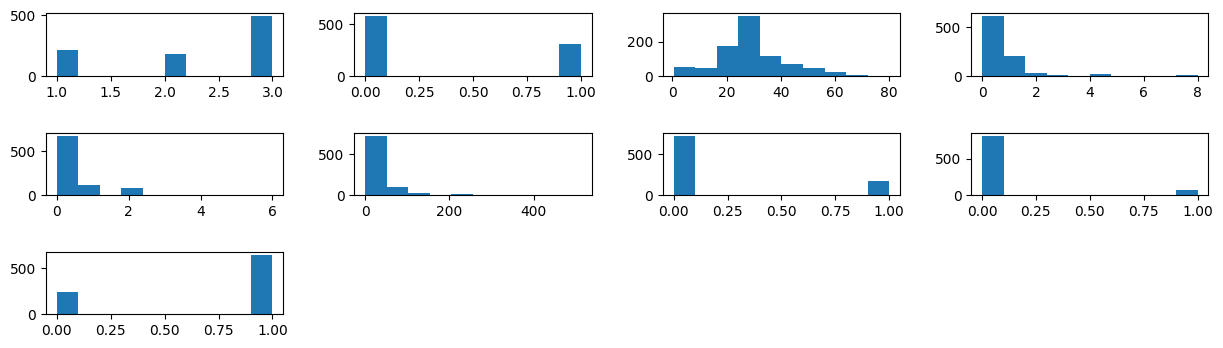

MultinomialNB()
[[455  94]
 [183 159]]
Accuracy=  0.6891133557800224
F1_score=  0.534453781512605
BernoulliNB()
[[457  92]
 [100 242]]
Accuracy=  0.7845117845117845
F1_score=  0.7159763313609467
CategoricalNB()
[[488  61]
 [104 238]]
Accuracy=  0.8148148148148148
F1_score=  0.7425897035881436
ComplementNB()
[[454  95]
 [178 164]]
Accuracy=  0.6936026936026936
F1_score=  0.5457570715474209


In [97]:
data = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/2024/ML3.6%20bayes/titanic.csv', index_col=0)

X = data.drop('Survived', axis=1)
y = data['Survived']

f = plt.figure(figsize=(15, 7))
for i in range(X.shape[1]):
    plt.subplot(5, 4, i+1)
    plt.hist(X.iloc[:, i])
f.subplots_adjust(hspace=0.9,wspace=0.3)
plt.show()

for model in models:
    print(model)
    model.fit(X, y)
    y_predict = model.predict(X)
    print(confusion_matrix(y, y_predict))
    print('Accuracy= ', metrics.accuracy_score(y, y_predict))
    print('F1_score= ', metrics.f1_score(y, y_predict))

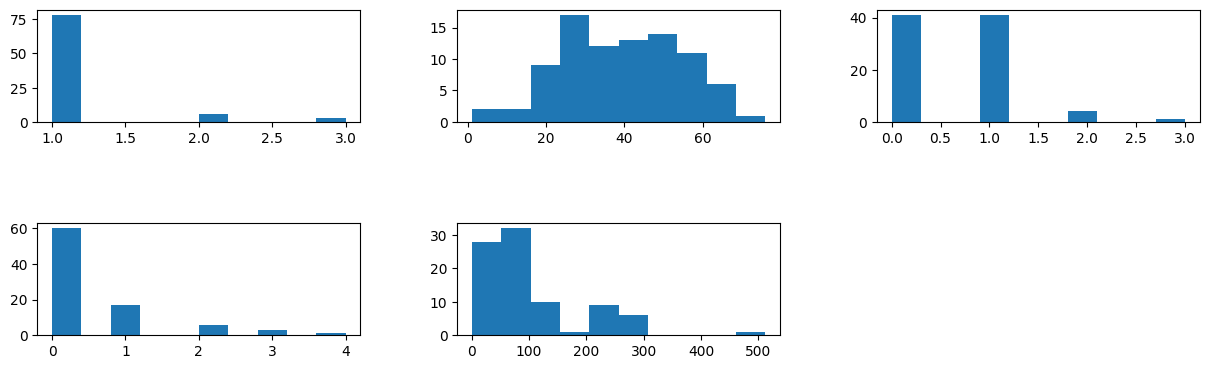

GaussianNB()
[[31 12]
 [24 20]]
Accuracy=  0.5862068965517241
F1_score=  0.5263157894736842
MultinomialNB()
[[30 13]
 [23 21]]
Accuracy=  0.5862068965517241
F1_score=  0.5384615384615384
BernoulliNB()
[[34  9]
 [26 18]]
Accuracy=  0.5977011494252874
F1_score=  0.5070422535211268
CategoricalNB()
[[37  6]
 [ 6 38]]
Accuracy=  0.8620689655172413
F1_score=  0.8636363636363636
ComplementNB()
[[30 13]
 [23 21]]
Accuracy=  0.5862068965517241
F1_score=  0.5384615384615384


In [126]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("brendan45774/test-file")

file_path = os.path.join(path, "tested.csv")

df = pd.read_csv(file_path, index_col=0)
df = df.dropna()

X = df.drop(['Survived', 'Name', 'Sex', 'Cabin', 'Ticket', 'Embarked'], axis=1)
y = df['Survived']

f = plt.figure(figsize=(15, 7))
for i in range(X.shape[1]):
    plt.subplot(3, 3, i+1)
    plt.hist(X.iloc[:, i])
f.subplots_adjust(hspace=0.9,wspace=0.3)
plt.show()

models = [GaussianNB(), MultinomialNB(), BernoulliNB(), CategoricalNB(), ComplementNB()]

for model in models:
    print(model)
    model.fit(X, y)
    y_predict = model.predict(X)
    print(confusion_matrix(y, y_predict))
    print('Accuracy= ', metrics.accuracy_score(y, y_predict))
    print('F1_score= ', metrics.f1_score(y, y_predict))
